<a href="https://colab.research.google.com/github/chanindu34/IPL_Data_Analysis/blob/main/IPL_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df1 = pd.read_csv("/matches.csv")
df1.head(3)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [5]:
df2 = pd.read_csv("/deliveries.csv")
df2.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


In [6]:
df1.count()

,0
id,1095
season,1095
city,1044
date,1095
match_type,1095
player_of_match,1090
venue,1095
team1,1095
team2,1095
toss_winner,1095


In [9]:
df1[df1['toss_winner'] == df1['winner']].count()

,0
id,554
season,554
city,534
date,554
match_type,554
player_of_match,554
venue,554
team1,554
team2,554
toss_winner,554


In [15]:
total_matches =df1['id'].count()
matches_toss_winner_won = df1[df1['toss_winner']==df1['winner']]['id'].count()
percentage = (matches_toss_winner_won/total_matches)*100


print(f"Total matches: {total_matches}")
print(f"Matches where toss winner also won: {matches_toss_winner_won}")
print(f"Percentage of matches where toss winner also won: {percentage:.2f}%")

Total matches: 1095
Matches where toss winner also won: 554
Percentage of matches where toss winner also won: 50.59%


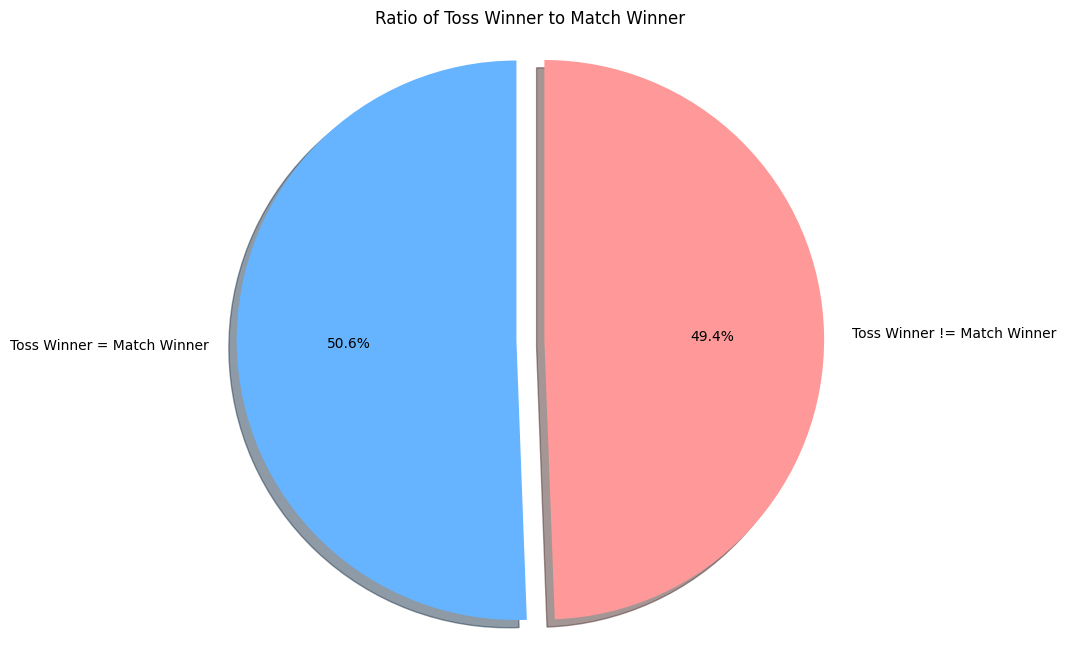

In [20]:
matches_toss_winner_lost = total_matches - matches_toss_winner_won

labels = ['Toss Winner = Match Winner', 'Toss Winner != Match Winner']
sizes = [matches_toss_winner_won, matches_toss_winner_lost]
colors = ['#66b3ff', '#ff9999']
explode = (0.1, 0)

fig1, ax1 = plt.subplots(figsize=(8, 8))
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal')
plt.title('Ratio of Toss Winner to Match Winner')
plt.show()

In [24]:
df1['winner'].value_counts().head()

,count
winner,
Mumbai Indians,144
Chennai Super Kings,138
Kolkata Knight Riders,131
Royal Challengers Bangalore,116
Rajasthan Royals,112


/tmp/ipykernel_13964/1023768230.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=winner_counts.index, y=winner_counts.values, palette='viridis')


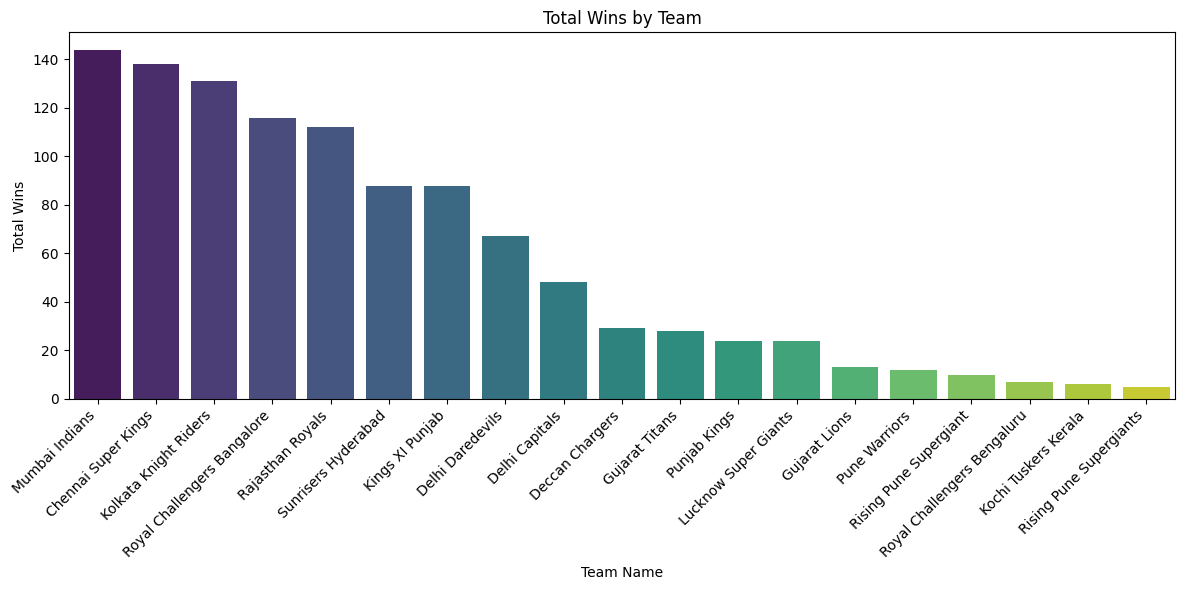

In [27]:
winner_counts = df1['winner'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=winner_counts.index, y=winner_counts.values, palette='viridis')
plt.xlabel('Team Name')
plt.ylabel('Total Wins')
plt.title('Total Wins by Team')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
df2.groupby('batter').agg(Batter_Runs=('batsman_runs', 'sum')).sort_values(by='Batter_Runs', ascending=False).head()

,Batter_Runs
batter,
V Kohli,8014
S Dhawan,6769
RG Sharma,6630
DA Warner,6567
SK Raina,5536
